# 01 Data Exploration and Gemini Filter

Mục tiêu của notebook này:

- Hiểu dữ liệu raw trước khi lọc: metadata, độ dài văn bản, phân bố loại văn bản và cấu trúc `Điều ...`.
- Dùng `gemini-3.1-flash-lite` để lọc corpus pháp luật lao động, không dùng keyword list thủ công.
- Lưu corpus đã lọc vào `data/processed/labor_corpus.jsonl` và summary vào `reports/labor_filter_summary.json`.

Các biểu đồ trong notebook này là EDA, không phải phần chọn retrieval method.

In [1]:
from pathlib import Path
from dataclasses import asdict, dataclass, field
from typing import Any, Iterator
from collections import Counter
import html
import itertools
import json
import math
import os
import re
import time

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

from dotenv import load_dotenv
from huggingface_hub import hf_hub_download
from IPython.display import Image, Markdown, display
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

DATASET_NAME = "th1nhng0/vietnamese-legal-documents"


@dataclass
class LegalDocument:
    id: str
    title: str | None = None
    so_ky_hieu: str | None = None
    ngay_ban_hanh: str | None = None
    loai_van_ban: str | None = None
    ngay_co_hieu_luc: str | None = None
    ngay_het_hieu_luc: str | None = None
    nguon_thu_thap: str | None = None
    ngay_dang_cong_bao: str | None = None
    nganh: str | None = None
    linh_vuc: str | None = None
    co_quan_ban_hanh: str | None = None
    chuc_danh: str | None = None
    nguoi_ky: str | None = None
    pham_vi: str | None = None
    thong_tin_ap_dung: str | None = None
    tinh_trang_hieu_luc: str | None = None
    content_html: str | None = None
    content_text: str | None = None
    source_url: str | None = None
    raw_metadata: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return asdict(self)


def normalize_text(text: str | None) -> str:
    text = html.unescape(text or "")
    text = re.sub(r"<script.*?</script>", " ", text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r"<style.*?</style>", " ", text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


ARTICLE_PATTERN = re.compile(r"(?=(?:Điều|ĐIỀU)\s+\d+[a-zA-Z]?\.)")
ARTICLE_HEADING_PATTERN = re.compile(r"(Điều\s+\d+[a-zA-Z]?\.)", flags=re.IGNORECASE)


def count_article_headings(text: str | None) -> int:
    return len(list(ARTICLE_PATTERN.finditer(normalize_text(text))))


def split_by_article_or_window(text: str, max_words: int = 260, overlap: int = 40) -> list[tuple[str | None, str]]:
    text = normalize_text(text)
    if not text:
        return []
    parts = [part.strip() for part in ARTICLE_PATTERN.split(text) if part.strip()]
    if len(parts) > 1:
        chunks = []
        for part in parts:
            article_match = re.match(r"(Điều\s+\d+[a-zA-Z]?)\.", part, flags=re.IGNORECASE)
            chunks.append((article_match.group(1) if article_match else None, part))
        return chunks
    words = text.split()
    chunks, start = [], 0
    while start < len(words):
        end = min(start + max_words, len(words))
        chunks.append((None, " ".join(words[start:end])))
        if end == len(words):
            break
        start = max(0, end - overlap)
    return chunks


def gemini_keys() -> list[str]:
    raw_values = [
        os.getenv("GOOGLE_API_KEY") or "",
        os.getenv("GEMINI_API_KEY") or "",
        os.getenv("GEMINI_API_KEYS") or "",
    ]
    keys = []
    for raw_value in raw_values:
        for key in raw_value.split(","):
            key = key.strip()
            if key and key not in keys:
                keys.append(key)
    return keys


class BatchGeminiClient:
    def __init__(self, api_keys: list[str] | None = None, model: str | None = None, rpm_limit: int = 12):
        self.api_keys = api_keys or gemini_keys()
        if not self.api_keys:
            raise ValueError("Set GEMINI_API_KEY or GEMINI_API_KEYS")
        self.model = model or os.getenv("GEMINI_MODEL", "gemini-3.1-flash-lite")
        self.sleep_seconds = 60 / max(1, rpm_limit)
        self._key_cycle = itertools.cycle(self.api_keys)
        self._last_request_at = {api_key: 0.0 for api_key in self.api_keys}

    @staticmethod
    def is_quota_error(error: Exception) -> bool:
        message = str(error)
        return "429" in message or "RESOURCE_EXHAUSTED" in message or "quota" in message.lower()

    def generate(self, prompt: str) -> str:
        from google import genai

        last_error = None
        for _ in range(len(self.api_keys)):
            api_key = next(self._key_cycle)
            try:
                self._wait_for_rate_limit(api_key)
                client = genai.Client(api_key=api_key)
                response = client.models.generate_content(model=self.model, contents=prompt)
                return response.text or ""
            except Exception as exc:
                last_error = exc
                if not self.is_quota_error(exc):
                    continue
        raise RuntimeError(f"Gemini generation failed for all keys: {last_error}")

    def _wait_for_rate_limit(self, api_key: str) -> None:
        elapsed = time.monotonic() - self._last_request_at[api_key]
        wait_seconds = self.sleep_seconds - elapsed
        if wait_seconds > 0:
            time.sleep(wait_seconds)
        self._last_request_at[api_key] = time.monotonic()


OUTPUT_CORPUS = PROJECT_ROOT / "data/processed/labor_corpus.jsonl"
AUDIT_CACHE = PROJECT_ROOT / "reports/labor_filter_gemini.jsonl"
SUMMARY_JSON = PROJECT_ROOT / "reports/labor_filter_summary.json"
FIGURES_DIR = PROJECT_ROOT / "reports/figures"

MODEL = "gemini-3.1-flash-lite"
PROMPT_VERSION = "labor_filter_v1"
GEMINI_FILTER_RPM_PER_KEY = 12
DAILY_REQUEST_BUFFER_PER_KEY = 450
BATCH_SIZE = 120
MAX_CONTENT_CHARS = 500
CONFIDENCE_THRESHOLD = 0.70

OUTPUT_CORPUS.parent.mkdir(parents=True, exist_ok=True)
AUDIT_CACHE.parent.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
load_dotenv(PROJECT_ROOT / ".env")


C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## 1. Load Raw Dataset

Dataset gốc có hai bảng parquet: metadata và content. Notebook chỉ giữ metadata trong RAM; content được stream để EDA và filter.

In [2]:
def dataset_file(filename: str) -> str:
    return hf_hub_download(repo_id=DATASET_NAME, filename=filename, repo_type="dataset")


def iter_parquet_rows(parquet_file, columns: list[str] | None = None) -> Iterator[dict]:
    for batch in parquet_file.iter_batches(batch_size=512, columns=columns):
        yield from batch.to_pylist()


metadata_file = pq.ParquetFile(dataset_file("data/metadata.parquet"))
content_file = pq.ParquetFile(dataset_file("data/content.parquet"))
metadata_by_id = {str(row["id"]): row for row in iter_parquet_rows(metadata_file)}
metadata_df = pd.DataFrame(metadata_by_id.values())

overview = pd.DataFrame([
    {"table": "metadata", "rows": metadata_file.metadata.num_rows, "columns": len(metadata_file.schema.names)},
    {"table": "content", "rows": content_file.metadata.num_rows, "columns": len(content_file.schema.names)},
    {"table": "metadata_by_id", "rows": len(metadata_by_id), "columns": None},
])
display(overview)
display(metadata_df[["id", "title", "loai_van_ban", "nganh", "linh_vuc", "co_quan_ban_hanh"]].head(8))


,table,rows,columns
0,metadata,153420,17.0
1,content,178665,2.0
2,metadata_by_id,153420,NaN


,id,title,loai_van_ban,nganh,linh_vuc,co_quan_ban_hanh
0,72,Sắc lệnh quy định liên hệ giữa UBKCHC và các c...,Sắc lệnh,NaN,NaN,Chủ tịch nước
1,4260,Về việc chuyển giao nhiệm vụ quản lý Nhà nước ...,Quyết định,NaN,NaN,UBND tỉnh Lâm Đồng
2,4280,Về viẹc quản lý và quy định thống nhất phí chợ...,Quyết định,Tài chính,NaN,UBND tỉnh Lâm Đồng
3,4263,Về việc xử lý đối với quỹ nhà thuộc quyền sở h...,Quyết định,Xây dựng,NaN,UBND tỉnh Lâm Đồng
4,77,Sắc lệnh bãi bỏ Sắc lệnh 106 ngày 09-09-1949 v...,Sắc lệnh,NaN,NaN,Chủ tịch nước
5,75,Sắc lệnh bổ nhiệm cán bộ giữ chức Đổng lý Văn ...,Sắc lệnh,NaN,NaN,Chủ tịch nước
6,58,Sắc lệnh chấp nhận đơn xin từ chức của bác sĩ ...,Sắc lệnh,NaN,NaN,Chủ tịch nước
7,95,Sắc lệnh bổ nhiệm ông Nguyễn Xuân Ngọc giữ chứ...,Sắc lệnh,NaN,NaN,Chủ tịch nước


## 2. Raw Data Profile

Phần này nhìn vào dữ liệu thật trước khi lọc. `ARTICLE_PATTERN` được dùng để đếm heading `Điều ...` và kiểm tra corpus có cấu trúc điều luật hay chỉ là văn bản dài cần window chunking.

In [3]:
def make_document(metadata_row: dict, content_html: str) -> LegalDocument:
    data = dict(metadata_row)
    data["id"] = str(data["id"])
    data["content_text"] = normalize_text(content_html)
    return LegalDocument(**data)


def iter_source_documents() -> Iterator[LegalDocument]:
    seen_ids = set()
    for content_row in iter_parquet_rows(content_file, columns=["id", "content_html"]):
        doc_id = str(content_row["id"])
        if doc_id in seen_ids:
            continue
        seen_ids.add(doc_id)
        metadata_row = metadata_by_id.get(doc_id)
        if metadata_row is None:
            continue
        yield make_document(metadata_row, content_row.get("content_html", ""))


def compact_document(document: LegalDocument) -> dict:
    return {
        "id": document.id,
        "title": document.title,
        "so_ky_hieu": document.so_ky_hieu,
        "ngay_ban_hanh": document.ngay_ban_hanh,
        "loai_van_ban": document.loai_van_ban,
        "ngay_co_hieu_luc": document.ngay_co_hieu_luc,
        "ngay_het_hieu_luc": document.ngay_het_hieu_luc,
        "nganh": document.nganh,
        "linh_vuc": document.linh_vuc,
        "co_quan_ban_hanh": document.co_quan_ban_hanh,
        "pham_vi": document.pham_vi,
        "tinh_trang_hieu_luc": document.tinh_trang_hieu_luc,
        "content_text": document.content_text,
        "source_url": document.source_url,
    }


raw_records, article_examples = [], []
for document in iter_source_documents():
    text = document.content_text or ""
    word_count = len(text.split())
    article_count = count_article_headings(text)
    chunk_count = len(split_by_article_or_window(text))
    raw_records.append({
        "id": document.id,
        "title": document.title,
        "loai_van_ban": document.loai_van_ban or "unknown",
        "nganh": document.nganh or "unknown",
        "linh_vuc": document.linh_vuc or "unknown",
        "co_quan_ban_hanh": document.co_quan_ban_hanh or "unknown",
        "word_count": word_count,
        "char_count": len(text),
        "article_count": article_count,
        "chunk_count": chunk_count,
        "has_article_heading": article_count > 0,
    })
    if article_count >= 3 and len(article_examples) < 8:
        headings = ARTICLE_HEADING_PATTERN.findall(text)[:8]
        article_examples.append({
            "id": document.id,
            "title": document.title,
            "article_count": article_count,
            "first_headings": ", ".join(headings),
        })

raw_df = pd.DataFrame(raw_records)
raw_summary = pd.DataFrame([{
    "documents": len(raw_df),
    "median_words": int(raw_df["word_count"].median()),
    "p95_words": int(raw_df["word_count"].quantile(0.95)),
    "documents_with_article_headings": int(raw_df["has_article_heading"].sum()),
    "article_heading_rate": raw_df["has_article_heading"].mean(),
    "median_chunks_per_doc": int(raw_df["chunk_count"].median()),
}])
display(raw_summary)
display(raw_df[["id", "title", "loai_van_ban", "word_count", "article_count", "chunk_count"]].head(10))


,documents,median_words,p95_words,documents_with_article_headings,article_heading_rate,median_chunks_per_doc
0,146857,871,7638,98719,0.672212,4


,id,title,loai_van_ban,word_count,article_count,chunk_count
0,4260,Về việc chuyển giao nhiệm vụ quản lý Nhà nước ...,Quyết định,771,0,4
1,4266,"Về việc tăng cường công tác quản lý nhà, đất v...",Chỉ thị,733,0,4
2,4262,Về việc tăng cường quản lý đất lâm nghiệp,Chỉ thị,1325,0,6
3,4264,Về việc kinh doanh mặt hàng rượu,Chỉ thị,590,0,3
4,4281,Quản lý thống nhất việc thu phí vào cổng tham ...,Quyết định,411,0,2
5,4265,Về việc thực hiện Quyết định số 53/1999/QĐ-TTg...,Chỉ thị,645,0,3
6,4299,Về việc quy định chế độ công tác phí Hội nghị ...,Quyết định,456,0,2
7,4273,Về việc chuyển chức năng QLNN về Thể dục thể t...,Quyết định,361,0,2
8,4274,Về việc giao chỉ tiêu kế hoạch động viên và hu...,Quyết định,601,0,3
9,4286,Về việc ban hành Qui chế hoạt động của Hội đồn...,Quyết định,1435,0,7


### raw_doc_type_distribution.png

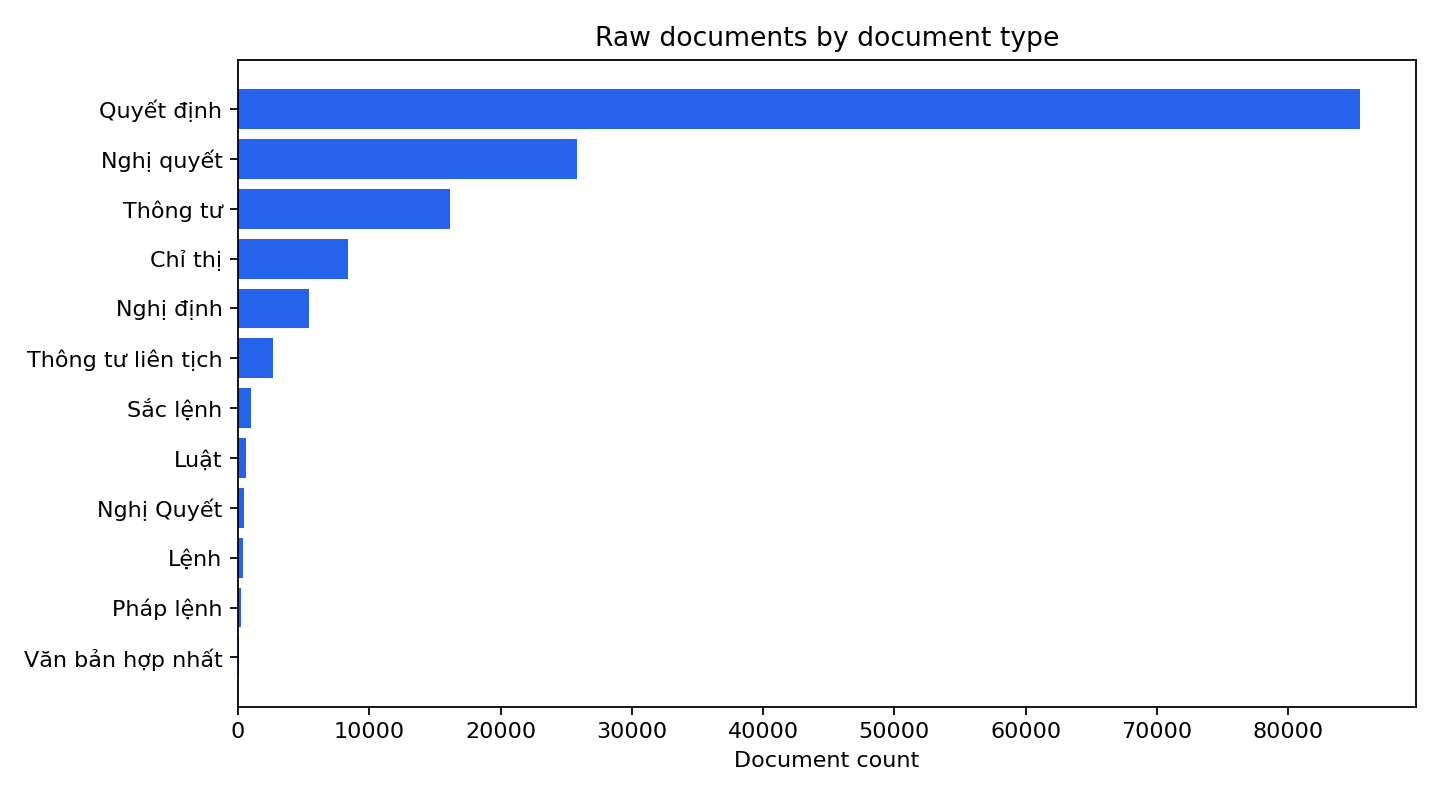

### raw_sector_distribution.png

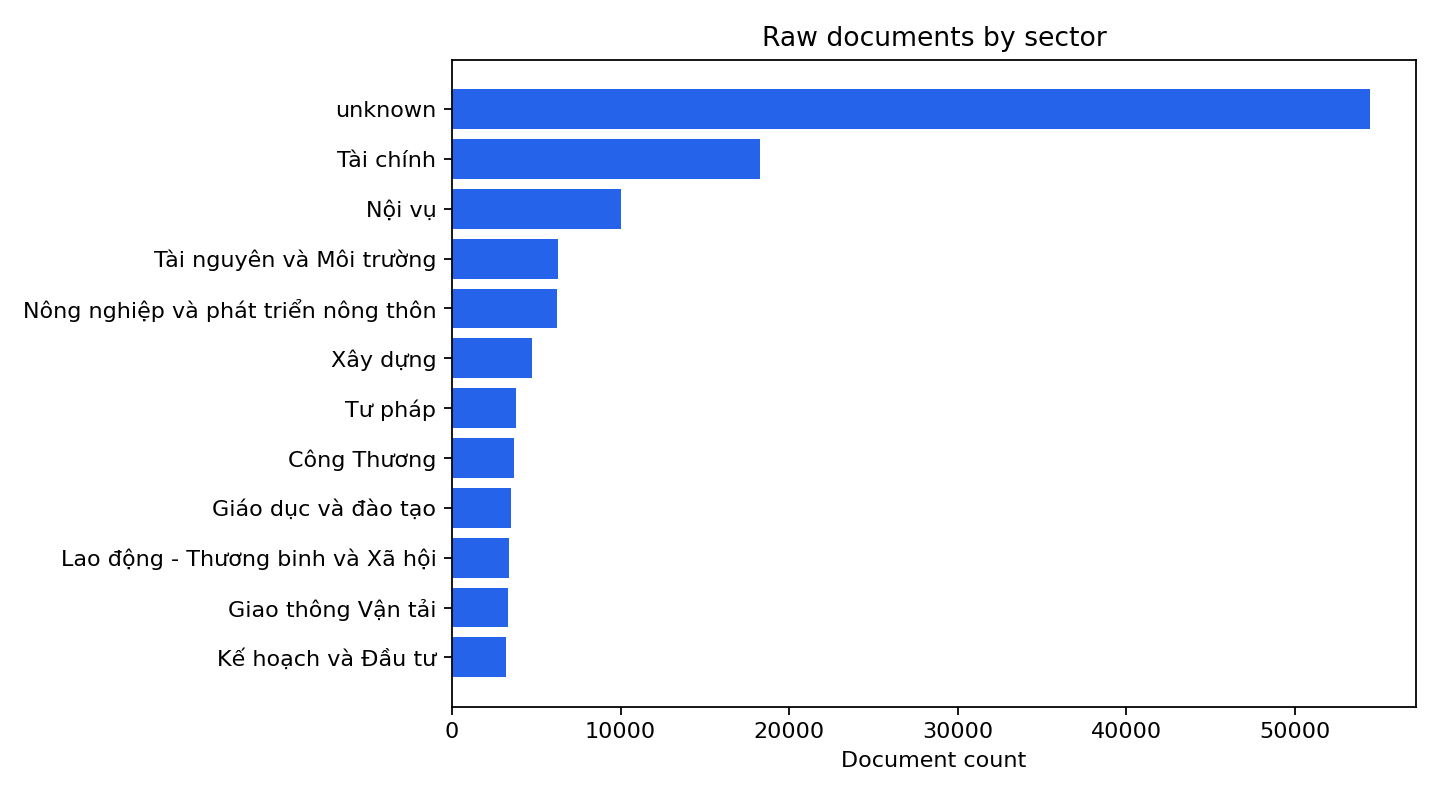

### raw_content_words_distribution.png

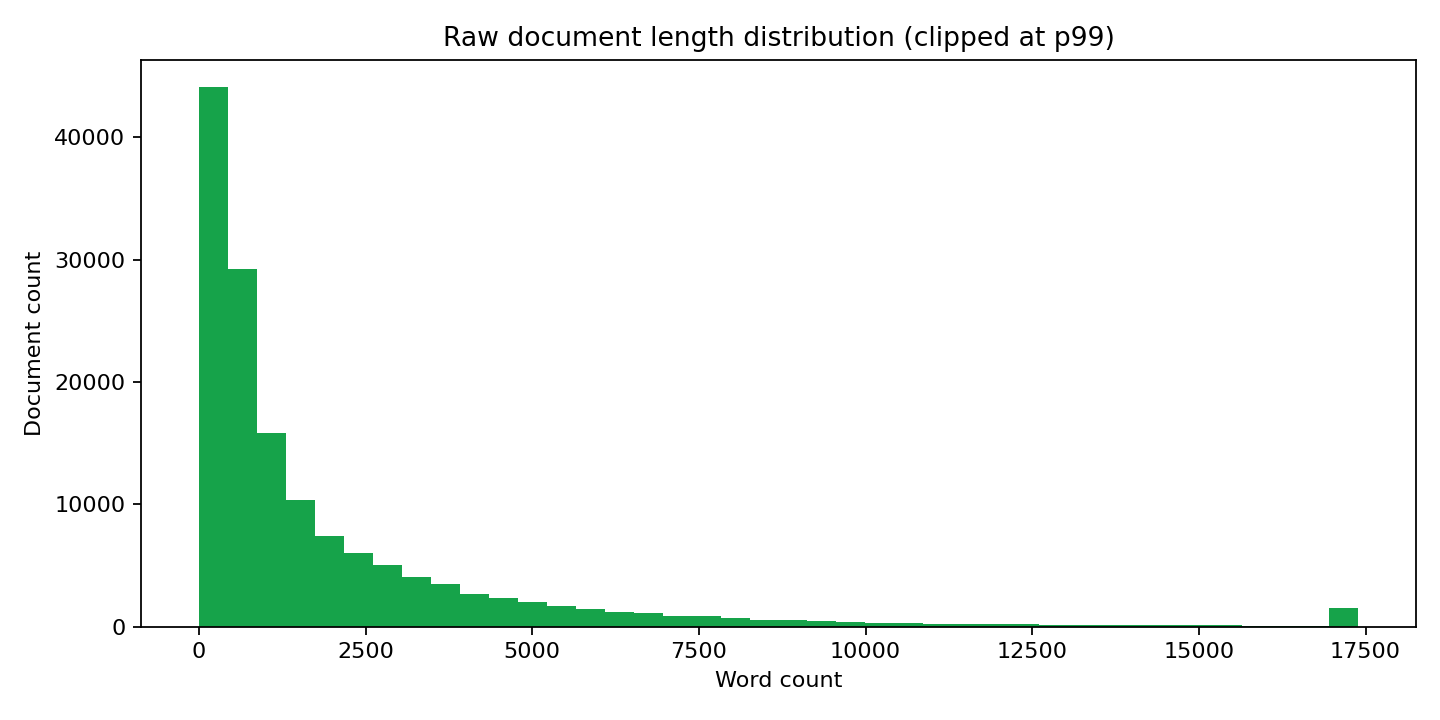

### raw_article_headings_distribution.png

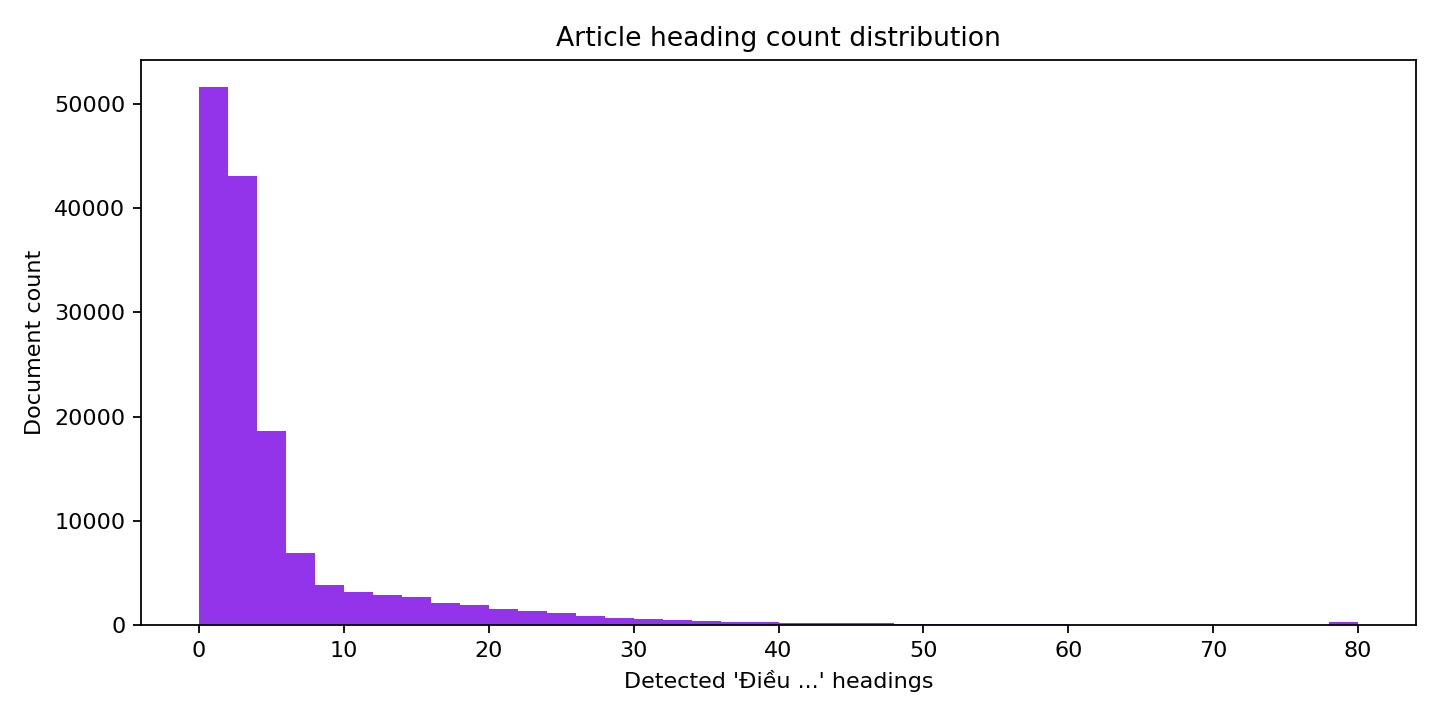

In [4]:
def save_bar(series, title: str, path: Path, top_n: int = 12) -> None:
    values = series.fillna("unknown").astype(str).value_counts().head(top_n).sort_values()
    plt.figure(figsize=(9, 5))
    plt.barh(values.index, values.values, color="#2563eb")
    plt.title(title)
    plt.xlabel("Document count")
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()


save_bar(raw_df["loai_van_ban"], "Raw documents by document type", FIGURES_DIR / "raw_doc_type_distribution.png")
save_bar(raw_df["nganh"], "Raw documents by sector", FIGURES_DIR / "raw_sector_distribution.png")

plt.figure(figsize=(9, 4.5))
plt.hist(raw_df["word_count"].clip(upper=raw_df["word_count"].quantile(0.99)), bins=40, color="#16a34a")
plt.title("Raw document length distribution (clipped at p99)")
plt.xlabel("Word count")
plt.ylabel("Document count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "raw_content_words_distribution.png", dpi=160)
plt.close()

plt.figure(figsize=(9, 4.5))
plt.hist(raw_df["article_count"].clip(upper=80), bins=40, color="#9333ea")
plt.title("Article heading count distribution")
plt.xlabel("Detected 'Điều ...' headings")
plt.ylabel("Document count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "raw_article_headings_distribution.png", dpi=160)
plt.close()

for name in [
    "raw_doc_type_distribution.png",
    "raw_sector_distribution.png",
    "raw_content_words_distribution.png",
    "raw_article_headings_distribution.png",
]:
    display(Markdown(f"### {name}"))
    display(Image(filename=str(FIGURES_DIR / name)))


## 3. Article Split Sanity Check

Đây là chỗ kiểm tra trực tiếp regex `ARTICLE_PATTERN`. Nếu văn bản có nhiều heading `Điều ...`, chunking sẽ tách theo điều; nếu không có heading thì mới dùng sliding window.

In [5]:
display(pd.DataFrame(article_examples))

sample_document = next(document for document in iter_source_documents() if count_article_headings(document.content_text) >= 3)
sample_chunks = split_by_article_or_window(sample_document.content_text)
split_preview = pd.DataFrame([
    {
        "chunk_no": idx + 1,
        "article": article,
        "words": len(text.split()),
        "preview": text[:220],
    }
    for idx, (article, text) in enumerate(sample_chunks[:10])
])
display(Markdown(f"Sample document: **{sample_document.title}**"))
display(split_preview)


,id,title,article_count,first_headings
0,4207,"Về việc ban hành qui định chức năng, nhiệm vụ,...",3,"Điều 3., Điều 4., Điều 5."
1,4205,"Về việc ban hành quy định chức năng nhiệm vụ, ...",5,"Điều 1., Điều 2., Điều 3., Điều 4., Điều 5."
2,4206,Về việc chuyển đổi hình thức hoạt động từ đơn ...,4,"Điều 1., Điều 2., Điều 3., Điều 4."
3,7,Đặt thể lệ cho công chức và gia đình công chức...,23,"Điều 1., Điều 2., Điều 3., Điều 4., Điều 5., Đ..."
4,2298,"Về chức năng, nhiệm vụ quyền hạn và tổ chức củ...",5,"Điều 1., Điều 2., Điều 3., Điều 4., Điều 5."
5,2295,Về thủ tục kết hôn giữa công dân Việt Nam với ...,9,"Điều 1., Điều 2., Điều 3., Điều 4., Điều 5., Đ..."
6,4,Thành lập phòng giới thiệu công nhân tại Bộ La...,10,"Điều 1., Điều 2., Điều 3., Điều 4., điều 2., Đ..."
7,2,Thành lập tại mỗi liên khu một hội đồng ấn địn...,8,"Điều 1., Điều 2., Điều 3., Điều 4., Điều 5., Đ..."


Sample document: **Về việc ban hành qui định chức năng, nhiệm vụ, quyền hạn, tổ chức bộ máy và mối quan hệ công tác của Sở Xây dựng tỉnh Bắc Ninh**

,chunk_no,article,words,preview
0,1,NaN,1318,QUYẾT ĐỊNH CỦA UBND TỈNH BẮC NINH Về việc ban ...
1,2,Điều 3,324,Điều 3. Cơ cấu tổ chức bộ máy: 1. Lãnh đạo Sở:...
2,3,Điều 4,126,Điều 4. Mối quan hệ công tác: 1- Sở Xây dựng l...
3,4,Điều 5,111,Điều 5. Tổ chức thực hiện: 1- Căn cứ vào bản q...


## 4. Gemini Labor-Law Filter

Gemini phân loại theo metadata + title + excerpt, không dùng list keyword thủ công. Mỗi key chạy tối đa `12 RPM`, thấp hơn quota `15 RPM/key`; cache JSONL giúp rerun tiếp tục từ chỗ đã có.

In [6]:
def gemini_key_count() -> int:
    return len(gemini_keys())


def load_audit_cache() -> dict[str, dict]:
    if not AUDIT_CACHE.exists():
        return {}
    cache = {}
    with AUDIT_CACHE.open(encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            if row.get("prompt_version") == PROMPT_VERSION:
                cache[str(row["id"])] = row
    return cache


def append_audit_rows(rows: list[dict]) -> None:
    with AUDIT_CACHE.open("a", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def document_payload(document: LegalDocument) -> dict:
    return {
        "id": document.id,
        "title": document.title,
        "nganh": document.nganh,
        "linh_vuc": document.linh_vuc,
        "loai_van_ban": document.loai_van_ban,
        "co_quan_ban_hanh": document.co_quan_ban_hanh,
        "thong_tin_ap_dung": document.thong_tin_ap_dung,
        "content_excerpt": normalize_text(document.content_text)[:MAX_CONTENT_CHARS],
    }


def build_filter_prompt(batch: list[LegalDocument]) -> str:
    payload = [document_payload(document) for document in batch]
    return f"""
Bạn là bộ phân loại corpus cho dự án Vietnamese labor-law RAG.
Nhiệm vụ: xác định từng văn bản có thuộc pháp luật lao động hay không.

Accept nếu trọng tâm văn bản điều chỉnh quan hệ lao động, việc làm, tiền lương,
hợp đồng lao động, bảo hiểm xã hội/bảo hiểm thất nghiệp trong bối cảnh lao động,
công đoàn, an toàn vệ sinh lao động, đào tạo nghề, tranh chấp lao động.
Reject nếu chỉ nhắc lao động/cán bộ/công chức phụ trợ trong văn bản thuộc đất đai,
thuế, đầu tư, hình sự, y tế, giáo dục, tài chính hoặc thủ tục hành chính khác.

Trả về JSON duy nhất, không markdown:
{{"results":[{{"id":"...","is_labor_law":true,"confidence":0.0,"reason":"ngắn gọn"}}]}}

Documents:
{json.dumps(payload, ensure_ascii=False)}
""".strip()


def parse_json_response(text: str) -> dict:
    cleaned = re.sub(r"^```json|```$", "", text.strip(), flags=re.MULTILINE).strip()
    start = cleaned.find("{")
    end = cleaned.rfind("}")
    if start == -1 or end == -1:
        raise ValueError("Gemini response does not contain JSON")
    return json.loads(cleaned[start : end + 1])


def classify_batch(client: BatchGeminiClient, batch: list[LegalDocument]) -> list[dict]:
    prompt = build_filter_prompt(batch)
    parsed, last_error = None, None
    for _ in range(2):
        try:
            parsed = parse_json_response(client.generate(prompt))
            break
        except Exception as exc:
            last_error = exc
    if parsed is None:
        return [{
            "id": document.id,
            "title": document.title,
            "is_labor_law": False,
            "confidence": 0.0,
            "reason": f"classification_error: {last_error}",
            "model": MODEL,
            "prompt_version": PROMPT_VERSION,
            "cached": False,
        } for document in batch]
    by_id = {str(row.get("id")): row for row in parsed.get("results", [])}
    rows = []
    for document in batch:
        result = by_id.get(document.id, {})
        rows.append({
            "id": document.id,
            "title": document.title,
            "is_labor_law": bool(result.get("is_labor_law")),
            "confidence": float(result.get("confidence") or 0.0),
            "reason": str(result.get("reason") or ""),
            "model": MODEL,
            "prompt_version": PROMPT_VERSION,
            "cached": False,
        })
    return rows


In [7]:
cache = load_audit_cache()
key_count = gemini_key_count()
safe_request_budget = key_count * DAILY_REQUEST_BUFFER_PER_KEY
pending_batch, new_rows = [], []
request_count = 0
client = None

for document in iter_source_documents():
    if document.id in cache:
        continue
    pending_batch.append(document)
    if len(pending_batch) < BATCH_SIZE:
        continue
    if request_count >= safe_request_budget:
        break
    if client is None:
        client = BatchGeminiClient(model=MODEL, rpm_limit=GEMINI_FILTER_RPM_PER_KEY)
    rows = classify_batch(client, pending_batch)
    append_audit_rows(rows)
    cache.update({row["id"]: row for row in rows})
    new_rows.extend(rows)
    request_count += 1
    pending_batch = []
    if request_count == 1 or request_count % 25 == 0:
        print(f"requests={request_count}/{safe_request_budget}, cached={len(cache)}")

if pending_batch and request_count < safe_request_budget:
    if client is None:
        client = BatchGeminiClient(model=MODEL, rpm_limit=GEMINI_FILTER_RPM_PER_KEY)
    rows = classify_batch(client, pending_batch)
    append_audit_rows(rows)
    cache.update({row["id"]: row for row in rows})
    new_rows.extend(rows)
    request_count += 1

pd.DataFrame([{
    "keys": key_count,
    "new_requests": request_count,
    "new_decisions": len(new_rows),
    "cached_decisions": len(cache),
    "safe_request_budget": safe_request_budget,
}])


,keys,new_requests,new_decisions,cached_decisions,safe_request_budget
0,6,0,0,146857,2700


## 5. Write and Inspect Filtered Corpus

Corpus chỉ được ghi khi toàn bộ source document đã có decision trong cache. Nếu quota hết giữa chừng, rerun notebook để tiếp tục.

In [8]:
accepted_ids = set()
total_documents = 0
missing_decisions = 0
for document in iter_source_documents():
    total_documents += 1
    row = cache.get(document.id)
    if row is None:
        missing_decisions += 1
        continue
    if row.get("is_labor_law") and float(row.get("confidence") or 0.0) >= CONFIDENCE_THRESHOLD:
        accepted_ids.add(document.id)

completed = missing_decisions == 0
accepted_count = len(accepted_ids)
if completed:
    with OUTPUT_CORPUS.open("w", encoding="utf-8") as f:
        for document in iter_source_documents():
            if document.id in accepted_ids:
                f.write(json.dumps(compact_document(document), ensure_ascii=False) + "\n")
summary = {
    "model": MODEL,
    "prompt_version": PROMPT_VERSION,
    "rpm_per_key": GEMINI_FILTER_RPM_PER_KEY,
    "daily_request_buffer_per_key": DAILY_REQUEST_BUFFER_PER_KEY,
    "batch_size": BATCH_SIZE,
    "max_content_chars": MAX_CONTENT_CHARS,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "total_documents": total_documents,
    "cached_decisions": len(cache),
    "new_decisions": len(new_rows),
    "missing_decisions": missing_decisions,
    "accepted": accepted_count,
    "completed": completed,
    "output_written": completed,
}
SUMMARY_JSON.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
pd.DataFrame([summary])


,model,prompt_version,rpm_per_key,daily_request_buffer_per_key,batch_size,max_content_chars,confidence_threshold,total_documents,cached_decisions,new_decisions,missing_decisions,accepted,completed,output_written
0,gemini-3.1-flash-lite,labor_filter_v1,12,450,120,500,0.7,146857,146857,0,0,17379,True,True


,accepted_documents,median_words,p95_words,documents_with_article_headings
0,17379,912,6913,11718


,id,title,loai_van_ban,nganh,linh_vuc,word_count,article_count
0,4299,Về việc quy định chế độ công tác phí Hội nghị ...,Quyết định,Tài chính,NaN,456,0
1,4284,Về việc tăng cường quản lý nhà nước trong lĩnh...,Chỉ thị,NaN,NaN,1584,0
2,4295,Về việc quy định tạm thời mức bồi dưỡng tập lu...,Quyết định,Tài chính Văn hóa Thể thao và Du lịch,NaN,416,0
3,4276,"Về việc điều chỉnh danh mục các xã, phường, th...",Quyết định,NaN,NaN,610,0
4,74,Sắc lệnh ấn định lương và phụ cấp cho các công...,Sắc lệnh,NaN,NaN,196,0
5,83,Sắc lệnh ấn định lương và phụ cấp cho các cấp ...,Sắc lệnh,NaN,NaN,386,0
6,91,Sắc lệnh quy định chế độ công nhân giúp việc C...,Sắc lệnh,NaN,NaN,3225,0
7,36,Sắc lệnh sửa đổi Sắc lệnh số 200-SL ngày 8-7-1...,Sắc lệnh,NaN,NaN,243,0
8,4204,Ban hành quy định phân cấp quản lý công tác Tổ...,Quyết định,NaN,NaN,2665,1
9,96,Sắc lệnh ban hành Quy chế Công chức,Sắc lệnh,NaN,NaN,4802,0


### labor_doc_type_distribution.png

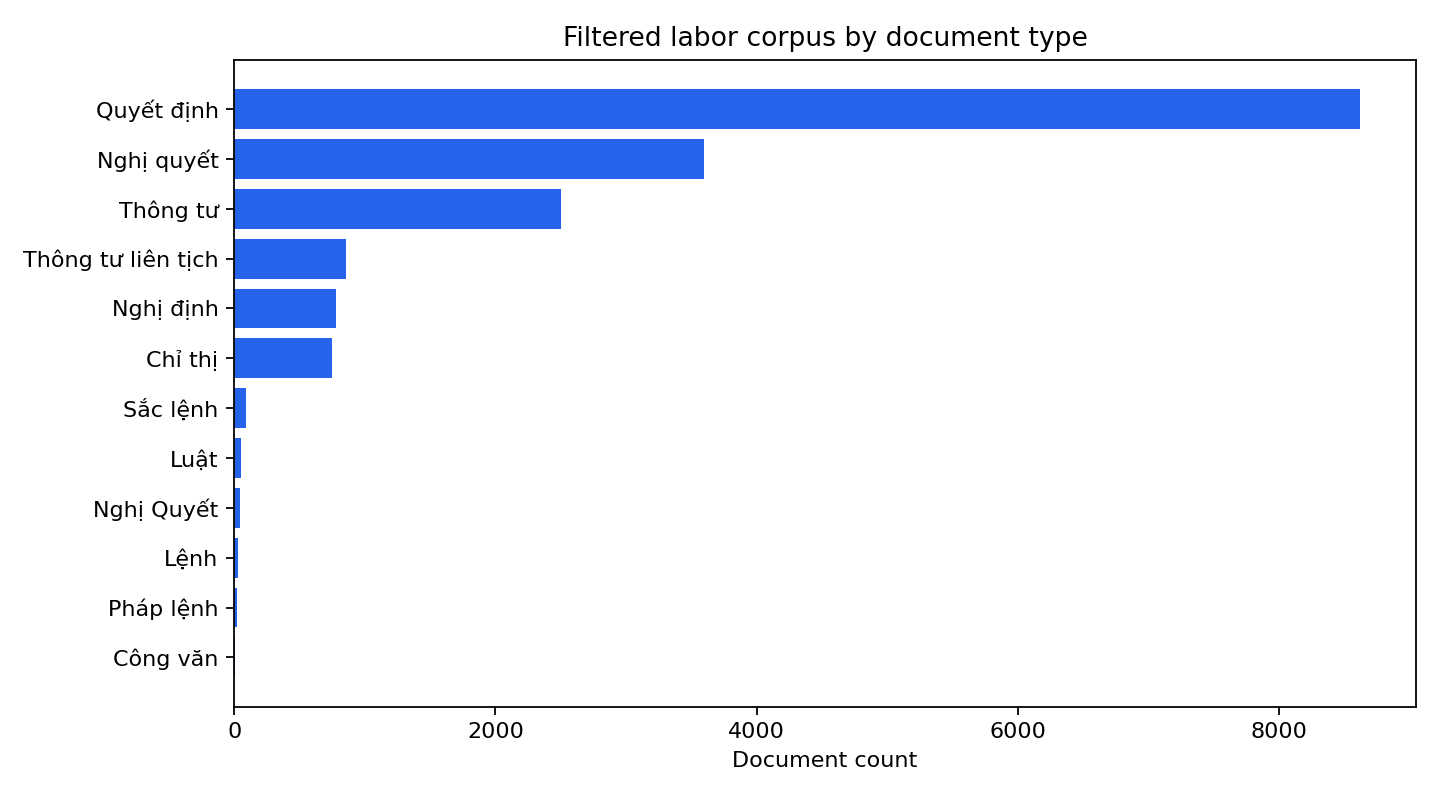

### labor_content_words_distribution.png

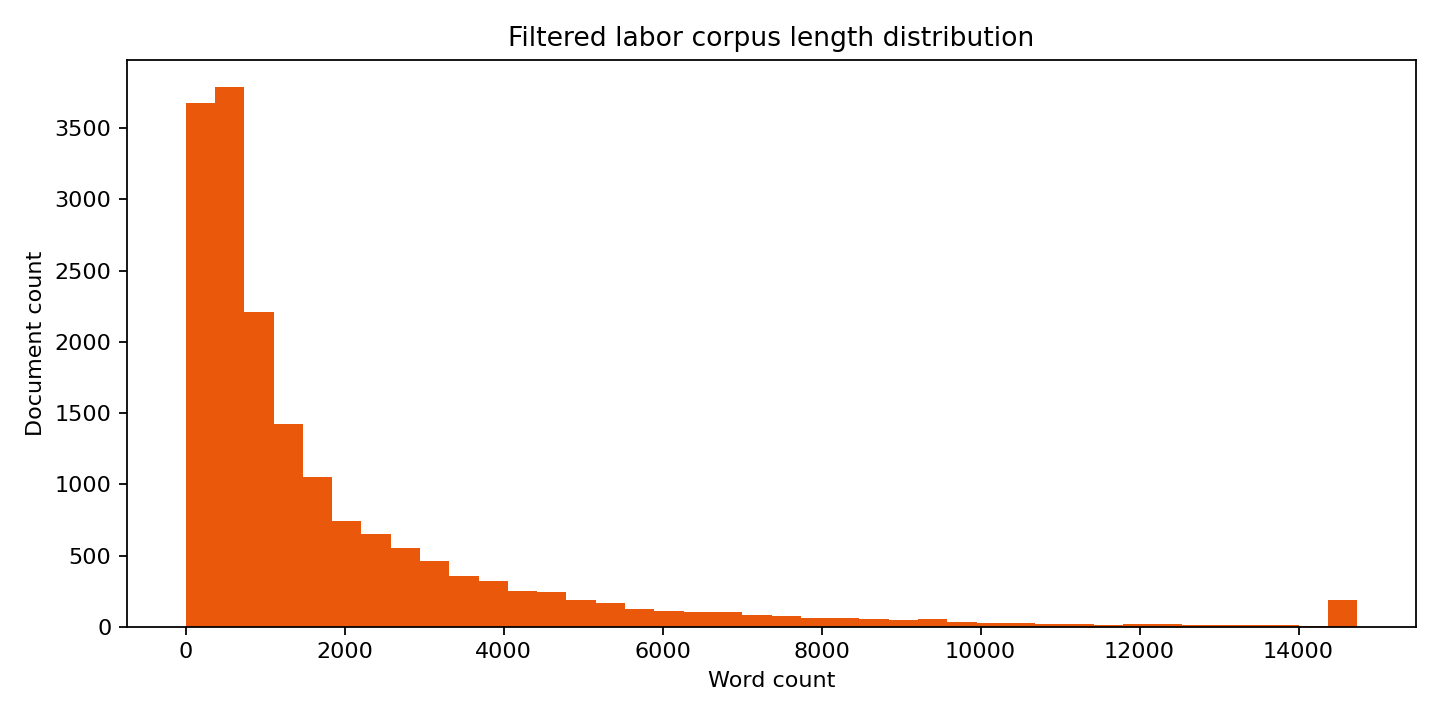

In [9]:
if OUTPUT_CORPUS.exists():
    accepted_rows = []
    with OUTPUT_CORPUS.open(encoding="utf-8") as f:
        for line in f:
            if line.strip():
                row = json.loads(line)
                row["word_count"] = len((row.get("content_text") or "").split())
                row["article_count"] = count_article_headings(row.get("content_text"))
                accepted_rows.append(row)
    accepted_df = pd.DataFrame(accepted_rows)

    display(pd.DataFrame([{
        "accepted_documents": len(accepted_df),
        "median_words": int(accepted_df["word_count"].median()),
        "p95_words": int(accepted_df["word_count"].quantile(0.95)),
        "documents_with_article_headings": int((accepted_df["article_count"] > 0).sum()),
    }]))
    display(accepted_df[["id", "title", "loai_van_ban", "nganh", "linh_vuc", "word_count", "article_count"]].head(12))

    save_bar(accepted_df["loai_van_ban"], "Filtered labor corpus by document type", FIGURES_DIR / "labor_doc_type_distribution.png")
    plt.figure(figsize=(9, 4.5))
    plt.hist(accepted_df["word_count"].clip(upper=accepted_df["word_count"].quantile(0.99)), bins=40, color="#ea580c")
    plt.title("Filtered labor corpus length distribution")
    plt.xlabel("Word count")
    plt.ylabel("Document count")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "labor_content_words_distribution.png", dpi=160)
    plt.close()

    for name in ["labor_doc_type_distribution.png", "labor_content_words_distribution.png"]:
        display(Markdown(f"### {name}"))
        display(Image(filename=str(FIGURES_DIR / name)))
else:
    display(Markdown("`labor_corpus.jsonl` chưa được ghi vì filter chưa hoàn tất. Rerun notebook để tiếp tục từ cache."))
